In [1]:
import sys
import os

sys.path.append(os.path.abspath('..')) 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib


In [3]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [4]:
from src.modeling.model import (
    scale_features,
    split_by_engines,
    get_xy
)

%load_ext autoreload
%autoreload 2

In [5]:
#load and prep data
df_train_features = pd.read_csv("../data/processed/train_features.csv")
df_test_features = pd.read_csv("../data/processed/test_features.csv")
print(df_train_features.shape, df_test_features.shape)



(20331, 94) (12796, 93)


In [6]:
#scale fit on train only
df_train_scaled, scaler = scale_features(df_train_features, is_fit=True)
df_test_scaled, _ = scale_features(df_test_features, scaler=scaler, is_fit=False)


In [7]:
# split by engine
df_train_split, df_val_split = split_by_engines(df_train_scaled, train_engines=70, val_engines=15)
X_train, y_train = get_xy(df_train_split)
X_val, y_val = get_xy(df_val_split)

print(X_train.shape, X_val.shape)

train: 13920 rows, val: 3165 rows
(13920, 91) (3165, 91)


In [8]:
# test set last cycle per engine
df_test_last = df_test_scaled.groupby('engine_number').last().reset_index()
X_test_last, _ = get_xy(df_test_last)
rul_test = pd.read_csv("../data/raw/RUL_FD001.txt", header=None, names=['true_RUL'])

print(X_test_last.shape, rul_test.shape)

(100, 91) (100, 1)


In [9]:
# baseline - linear regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_val)

lr_rmse = np.sqrt(mean_squared_error(y_val, y_pred_lr))
lr_mae = mean_absolute_error(y_val, y_pred_lr)
lr_r2 = r2_score(y_val, y_pred_lr)

print(f"LR - RMSE: {lr_rmse:.2f}, MAE: {lr_mae:.2f}, R2: {lr_r2:.4f}")

LR - RMSE: 21.43, MAE: 17.80, R2: 0.7560


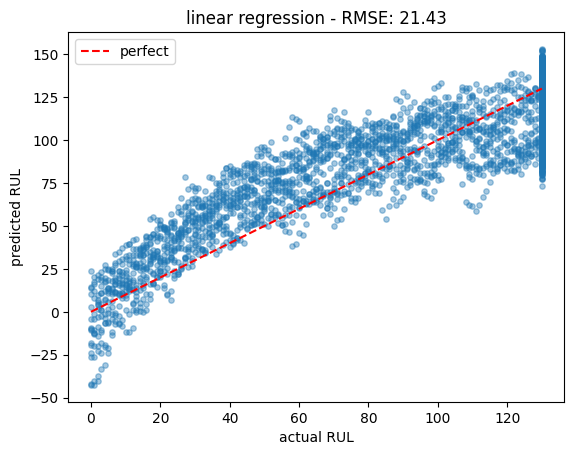

In [10]:
plt.scatter(y_val, y_pred_lr, alpha=0.4, s=15)
plt.plot([0, 130], [0, 130], 'r--', label='perfect')
plt.xlabel('actual RUL')
plt.ylabel('predicted RUL')
plt.title(f'linear regression - RMSE: {lr_rmse:.2f}')
plt.legend()
plt.show()

In [11]:
#predictions go negative for low RUL which is alinear regression limitation
#let's try ridge next

In [12]:
#maybe regularization helps
#tuning alpha
for alpha in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    print(f"alpha={alpha}: RMSE={rmse:.2f}")

alpha=0.001: RMSE=21.43
alpha=0.01: RMSE=21.43
alpha=0.1: RMSE=21.43
alpha=1.0: RMSE=21.43
alpha=10.0: RMSE=21.43
alpha=100.0: RMSE=21.52


In [13]:
#alpha doesn't make much difference here, all give ~21.43
#ridge not really better than linear regression
#random forest should do better
ridge_model = Ridge(alpha=1.0)  #justgonna use default
ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_val)

ridge_rmse = np.sqrt(mean_squared_error(y_val, y_pred_ridge))
ridge_mae = mean_absolute_error(y_val, y_pred_ridge)
ridge_r2 = r2_score(y_val, y_pred_ridge)

print(f"Ridge - RMSE: {ridge_rmse:.2f}, MAE: {ridge_mae:.2f}, R2: {ridge_r2:.4f}")

Ridge - RMSE: 21.43, MAE: 17.80, R2: 0.7560


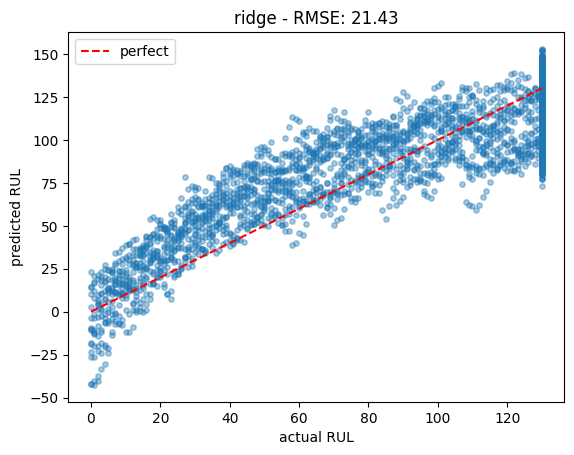

In [14]:
plt.scatter(y_val, y_pred_ridge, alpha=0.4, s=15)
plt.plot([0, 130], [0, 130], 'r--', label='perfect')
plt.title(f'ridge - RMSE: {ridge_rmse:.2f}')
plt.xlabel('actual RUL')
plt.ylabel('predicted RUL')
plt.legend()
plt.show()